# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Zaki Nanda Wahyudi | 5054251007|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [124]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, auc
from IPython.display import display
from scipy.stats import chi2_contingency

pd.set_option("display.show_dimensions", False)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [95]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
dataset = pd.read_csv("mushrooms.csv", na_values = '?')

print("="*10 + " 5 Baris Teratas " + "="*10)
dataset.head()


========== 5 Baris Teratas ==========


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [96]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print("=========== Ukuran Dataset ==========")
print(f"Dataset memiliki {dataset.shape[0]} baris dan {dataset.shape[1]} kolom")

print("\n\n========== Tipe Data ==========")
print(dataset.dtypes)

print("\n\n========== Jumlah Missing Value ==========")
missing_count = dataset.isnull().sum()
missing_percent = (dataset.isnull().sum() / len(dataset) * 100).round(2)
missing_df = pd.DataFrame(
    {"Jumlah Missing": missing_count, "Persentase(%)": missing_percent}
)
missing_df

=========== Ukuran Dataset ==========
Dataset memiliki 8124 baris dan 23 kolom


========== Tipe Data ==========
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object


========== Jumlah Missing Value ==========


,Jumlah Missing,Persentase(%)
class,0,0.000000
cap-shape,0,0.000000
cap-surface,0,0.000000
cap-color,0,0.000000
bruises,0,0.000000
odor,0,0.000000
gill-attachment,0,0.000000
gill-spacing,0,0.000000
gill-size,0,0.000000
gill-color,0,0.000000


In [97]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
print("========== Jumlah Nilai Unik Tiap Fitur ==========")
for col in dataset.columns:
    print(f"{col}: {dataset[col].nunique()}")

========== Jumlah Nilai Unik Tiap Fitur ==========
class: 2
cap-shape: 6
cap-surface: 4
cap-color: 10
bruises: 2
odor: 9
gill-attachment: 2
gill-spacing: 2
gill-size: 2
gill-color: 12
stalk-shape: 2
stalk-root: 4
stalk-surface-above-ring: 4
stalk-surface-below-ring: 4
stalk-color-above-ring: 9
stalk-color-below-ring: 9
veil-type: 1
veil-color: 4
ring-number: 3
ring-type: 5
spore-print-color: 9
population: 6
habitat: 7


========== Jumlah Sampel per Class ==========
class
e    4208
p    3916
Name: count, dtype: int64


========== Persentase Sampel per Class (%) ==========
class
e   0.520000
p   0.480000
Name: proportion, dtype: float64


========== Visualisasi Bar Plot ==========


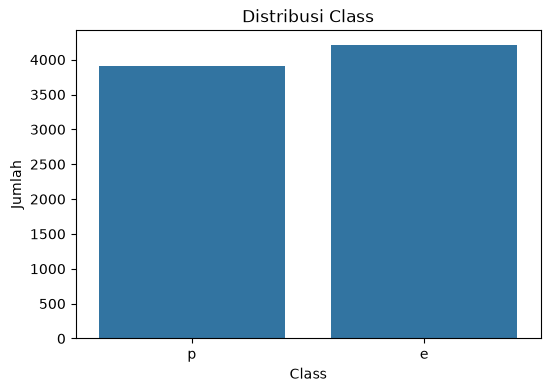

Berdasarkan visualisasi di atas, dapat kita ketahui bahwa dataset ini balanced


In [98]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print("========== Jumlah Sampel per Class ==========")
print(dataset["class"].value_counts())

print("\n\n========== Persentase Sampel per Class (%) ==========")
print(dataset["class"].value_counts(normalize= True).round(2))

print("\n\n========== Visualisasi Bar Plot ==========")
plt.figure(figsize= (6, 4))
sns.countplot(data = dataset, x = "class")
plt.title("Distribusi Class")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

print("Berdasarkan visualisasi di atas, dapat kita ketahui bahwa dataset ini balanced")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [99]:
print("========== Jumlah Baris Duplikat ==========")
print(f"Jumlah Baris Duplikat: {dataset.duplicated().sum()}")

========== Jumlah Baris Duplikat ==========
Jumlah Baris Duplikat: 0


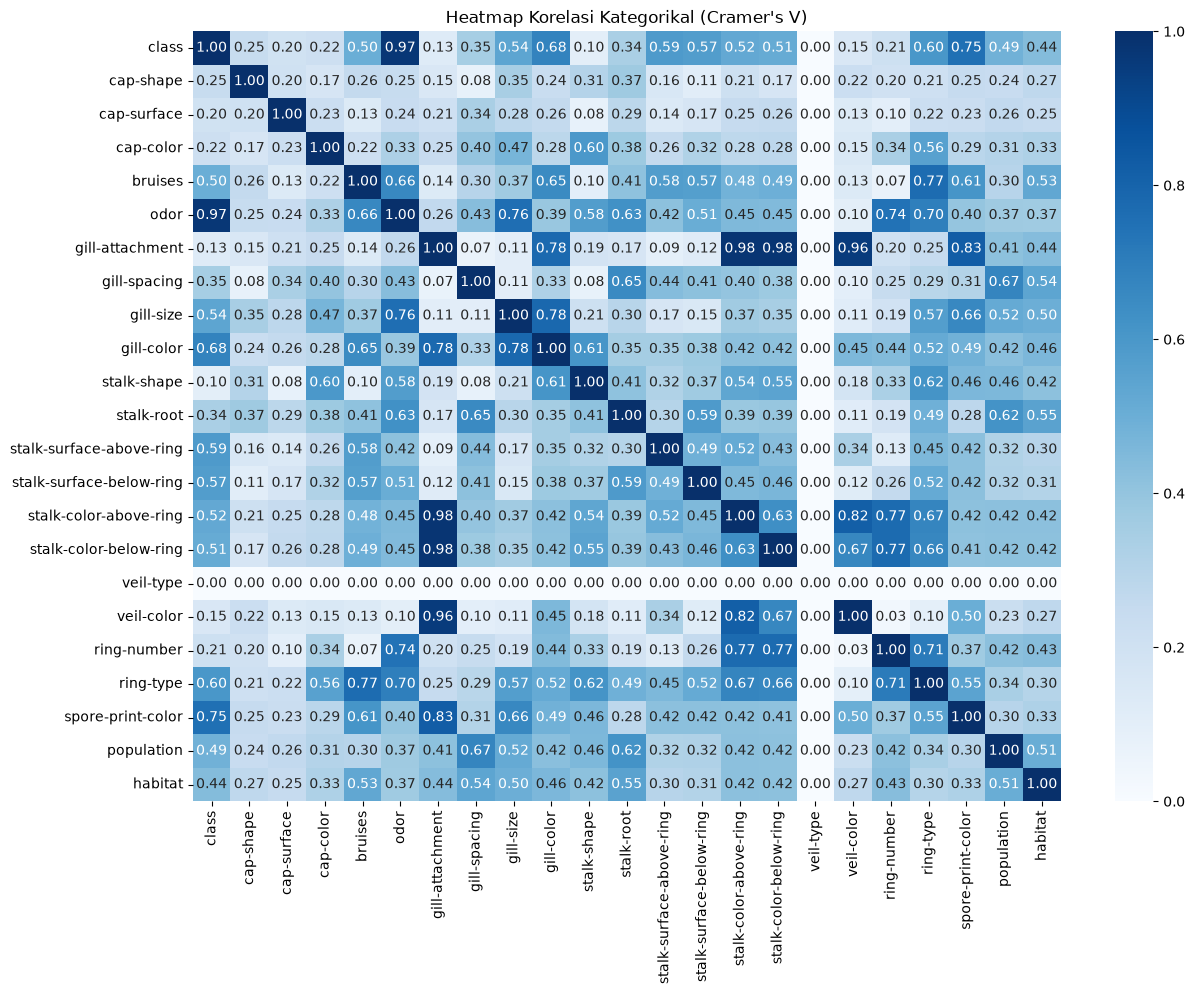

In [100]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    if min((k-1), (r-1)) == 0:
        return 0.0
    return np.sqrt(phi2 / min((k-1), (r-1)))

cols = dataset.columns
cramer_matrix = pd.DataFrame(index = cols, columns = cols, dtype = float)

for col1 in cols:
    for col2 in cols:
        cramer_matrix.loc[col1, col2] = cramers_v(dataset[col1], dataset[col2])

plt.figure(figsize = (14, 10))
sns.heatmap(cramer_matrix, annot = True, fmt = ".2f", cmap = "Blues")
plt.title("Heatmap Korelasi Kategorikal (Cramer's V)")
plt.show()
    

In [101]:
class_corr = cramer_matrix["class"].drop("class").sort_values(ascending = False)
print("========== Ranking Korelasi Fitur terhadap Class ==========")
print(class_corr)

========== Ranking Korelasi Fitur terhadap Class ==========
odor                       0.971005
spore-print-color          0.752645
gill-color                 0.680830
ring-type                  0.603271
stalk-surface-above-ring   0.587944
stalk-surface-below-ring   0.574837
gill-size                  0.539758
stalk-color-above-ring     0.524850
stalk-color-below-ring     0.514725
bruises                    0.501280
population                 0.487376
habitat                    0.440136
gill-spacing               0.348052
stalk-root                 0.336284
cap-shape                  0.245571
cap-color                  0.218427
ring-number                0.214772
cap-surface                0.196925
veil-color                 0.153421
gill-attachment            0.128424
stalk-shape                0.101770
veil-type                  0.000000
Name: class, dtype: float64


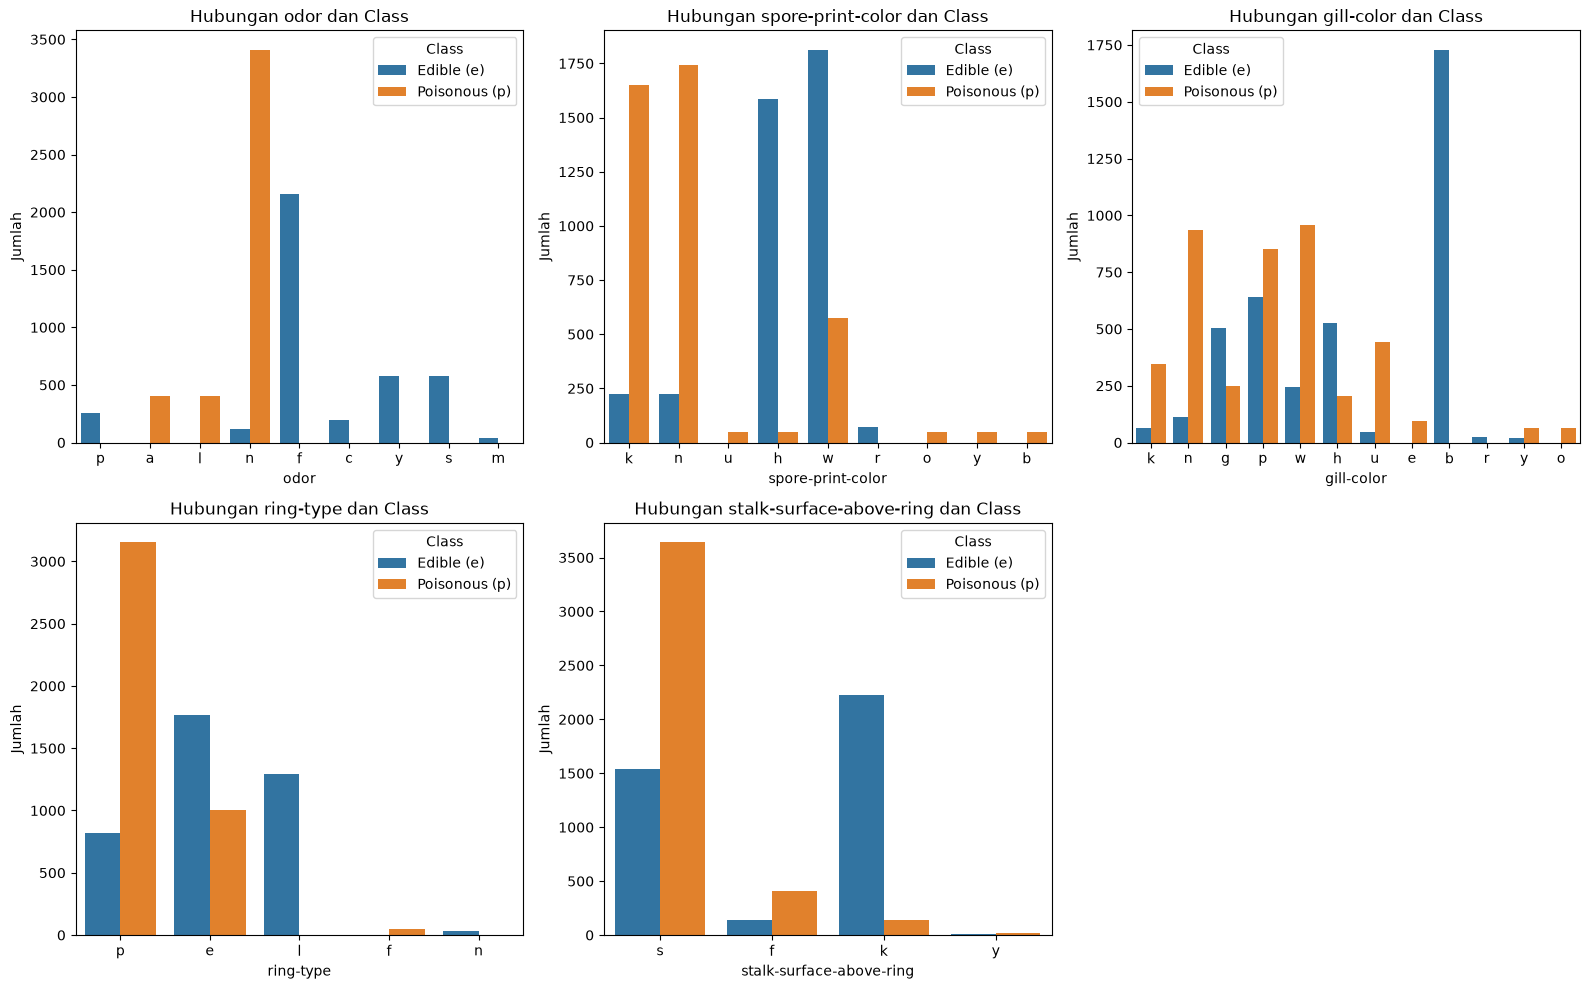


Fitur odor merupakan prediktor paling dominan dalam memisahkan kelas jamur (beberapa bau tertentu 100% beracun). 
Fitur pendukung seperti spore-print-color, gill-color, ring-type, dan stalk-surface-above-ring juga memperlihatkan pemisahan kategori yang signifikan.



In [102]:
top5_features = ["odor", "spore-print-color", "gill-color", "ring-type", "stalk-surface-above-ring"]
plt.figure(figsize = (16, 10))
for i, col in enumerate(top5_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data = dataset, x = col, hue = "class")
    plt.title(f"Hubungan {col} dan Class")
    plt.xlabel(col)
    plt.ylabel("Jumlah")
    plt.legend(title = "Class", labels = ["Edible (e)", "Poisonous (p)"])
plt.tight_layout()
plt.show()

print(
    '''
Fitur odor merupakan prediktor paling dominan dalam memisahkan kelas jamur (beberapa bau tertentu 100% beracun). 
Fitur pendukung seperti spore-print-color, gill-color, ring-type, dan stalk-surface-above-ring juga memperlihatkan pemisahan kategori yang signifikan.
'''
)

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [103]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
dataset["stalk-root"] = dataset["stalk-root"].fillna("missing")

print("================ STRATEGI PENANGANAN MISSING VALUE (stalk-root) ================")
print("Jumlah Missing Value: 2.480 dari 8.124 baris (~30.5%)\n")

print("--- Evaluasi Pilihan Strategi ---")
print("1. Drop Baris (Hapus Data Hilang):")
print("   [X] Tidak Dipilih -> Menghapus ~30,5% data menyebabkan information loss yang besar.\n")

print("2. Imputasi Modus (Ganti Kategori Terbanyak):")
print("   [X] Tidak Dipilih -> Mengisi sepertiga data dengan 1 nilai dominan merusak distribusi asli & memicu bias.\n")

print("3. Drop Kolom (Hapus Kolom stalk-root):")
print("   [X] Tidak Dipilih -> Nilai Cramér's V (~0,3) menunjukkan korelasi sedang, masih bernilai untuk model.\n")

print("4. Buat Kategori Tersendiri ('missing'):")
print("   [v] DIPILIH (Strategi Terbaik)")
print("   - Mempertahankan 100% sampel data (8.124 baris).")
print("   - Tidak menambahkan bias/asumsi palsu ke distribusi data.")
print("   - Memungkinkan algoritma (seperti Naive Bayes) mempelajari pola dari status ketidaktahuan/missing.")
print("=================================================================================")

================ STRATEGI PENANGANAN MISSING VALUE (stalk-root) ================
Jumlah Missing Value: 2.480 dari 8.124 baris (~30.5%)

--- Evaluasi Pilihan Strategi ---
1. Drop Baris (Hapus Data Hilang):
   [X] Tidak Dipilih -> Menghapus ~30,5% data menyebabkan information loss yang besar.

2. Imputasi Modus (Ganti Kategori Terbanyak):
   [X] Tidak Dipilih -> Mengisi sepertiga data dengan 1 nilai dominan merusak distribusi asli & memicu bias.

3. Drop Kolom (Hapus Kolom stalk-root):
   [X] Tidak Dipilih -> Nilai Cramér's V (~0,3) menunjukkan korelasi sedang, masih bernilai untuk model.

4. Buat Kategori Tersendiri ('missing'):
   [v] DIPILIH (Strategi Terbaik)
   - Mempertahankan 100% sampel data (8.124 baris).
   - Tidak menambahkan bias/asumsi palsu ke distribusi data.
   - Memungkinkan algoritma (seperti Naive Bayes) mempelajari pola dari status ketidaktahuan/missing.


In [104]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
dataset = dataset.drop(columns = ["veil-type"])

In [105]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = dataset.drop(columns = ["class"])
y = dataset["class"]

y = y.map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("========== Ukuran Split Dataset ==========")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print("\n========== Proporsi Class y_train (%) ==========")
print((y_train.value_counts(normalize = True) * 100).round(2))

print("\n========== Proporsi Class y_test (%) ==========")
print((y_test.value_counts(normalize = True) * 100).round(2))


========== Ukuran Split Dataset ==========
X_train: (6499, 21)
X_test: (1625, 21)

========== Proporsi Class y_train (%) ==========
class
0   51.790000
1   48.210000
Name: proportion, dtype: float64

========== Proporsi Class y_test (%) ==========
class
0   51.820000
1   48.180000
Name: proportion, dtype: float64


In [106]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
encoder_ord = OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1)

X_train_cat = encoder_ord.fit_transform(X_train)
X_test_cat = encoder_ord.transform(X_test)

X_train_cat = pd.DataFrame(X_train_cat, columns = X_train.columns, index = X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns = X_test.columns, index = X_test.index)

print("========== Sampel Hasil OrdinalEncoder (X_train_cat) ==========")
display(X_train_cat.head(3))

========== Sampel Hasil OrdinalEncoder (X_train_cat) ==========


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5249,2.000000,3.000000,9.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,...,1.000000,1.000000,6.000000,0.000000,2.000000,1.000000,2.000000,1.000000,5.000000,1.000000
5781,5.000000,2.000000,5.000000,1.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,2.000000,2.000000,2.000000,7.000000,2.000000,2.000000,0.000000,7.000000,1.000000,6.000000
7586,0.000000,2.000000,3.000000,0.000000,5.000000,1.000000,1.000000,0.000000,10.000000,0.000000,...,1.000000,2.000000,7.000000,7.000000,2.000000,2.000000,4.000000,7.000000,3.000000,1.000000


In [107]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
encoder_ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = True)

X_train_ohe = encoder_ohe.fit_transform(X_train)
X_test_ohe = encoder_ohe.transform(X_test)

print("========== Output OneHotEncoder ==========")
print(f"Tipe data matriks: {type(X_train_ohe)}")
print(f"Ukuran X_train_ohe: {X_train_ohe.shape}")
print(f"Ukuran X_test_ohe: {X_test_ohe.shape}")

========== Output OneHotEncoder ==========
Tipe data matriks: <class 'scipy.sparse._csr.csr_matrix'>
Ukuran X_train_ohe: (6499, 116)
Ukuran X_test_ohe: (1625, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [ ]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
model_cnb = CategoricalNB()

model_cnb.fit(X_train_cat, y_train)
print("Model Categorical NB berhasil dilatih!")

Model Categorical NB berhasil dilatih!


In [109]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_test_cnb = model_cnb.predict(X_test_cat)
y_prob_cnb = model_cnb.predict_proba(X_test_cat)[:, 1]

df_hasil_cnb = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred_test_cnb,
    "Prob_Poisonous": y_prob_cnb
})
display(df_hasil_cnb.head())

,Aktual,Prediksi,Prob_Poisonous
0,1,1,1.000000
1,1,0,0.369231
2,0,0,0.000002
3,1,1,1.000000
4,1,1,1.000000


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
model_bnb = BernoulliNB()

model_bnb.fit(X_train_ohe, y_train)
print("Model Bernoulli NB berhasil dilatih!")

Model Bernoulli NB berhasil dilatih!


In [111]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_test_bnb = model_bnb.predict(X_test_ohe)
y_prob_bnb = model_bnb.predict_proba(X_test_ohe)[:, 1]

df_hasil_bnb = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred_test_bnb,
    "Prob_Poisonous": y_prob_bnb
})

display(df_hasil_bnb.head())

,Aktual,Prediksi,Prob_Poisonous
0,1,1,1.000000
1,1,0,0.406872
2,0,0,0.000000
3,1,1,1.000000
4,1,1,1.000000


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
model_mnb = MultinomialNB()

model_mnb.fit(X_train_ohe, y_train)
print("Model Multinomial NB berhasil dilatih!")

Model Multinomial NB berhasil dilatih!


In [118]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_test_mnb = model_mnb.predict(X_test_ohe)
y_prob_mnb = model_mnb.predict_proba(X_test_ohe)[:, 1]

df_hasil_mnb = pd.DataFrame({
    "Aktual": y_test.values,
    "Predict": y_pred_test_mnb,
    "Prob_Poisonous": y_prob_mnb
})

display(df_hasil_mnb.head())

,Aktual,Predict,Prob_Poisonous
0,1,1,1.000000
1,1,0,0.369231
2,0,0,0.000002
3,1,1,1.000000
4,1,1,1.000000


# 4. Evaluasi Model

In [122]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

eval_cnb = evaluate_model(y_test, y_pred_test_cnb, y_prob_cnb)
eval_bnb = evaluate_model(y_test, y_pred_test_bnb, y_prob_bnb)
eval_mnb = evaluate_model(y_test, y_pred_test_mnb, y_prob_mnb)

df_eval = pd.DataFrame(
    [eval_cnb, eval_bnb, eval_mnb],
    index = ["Categorical NB", "Bernoulli NB", "Multinomial NB"]
)

display(df_eval.style.format("{:.4f}"))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Categorical NB,0.9458,0.9901,0.8966,0.9410,0.9972
Bernoulli NB,0.9329,0.9814,0.8774,0.9265,0.9954
Multinomial NB,0.9458,0.9901,0.8966,0.9410,0.9972


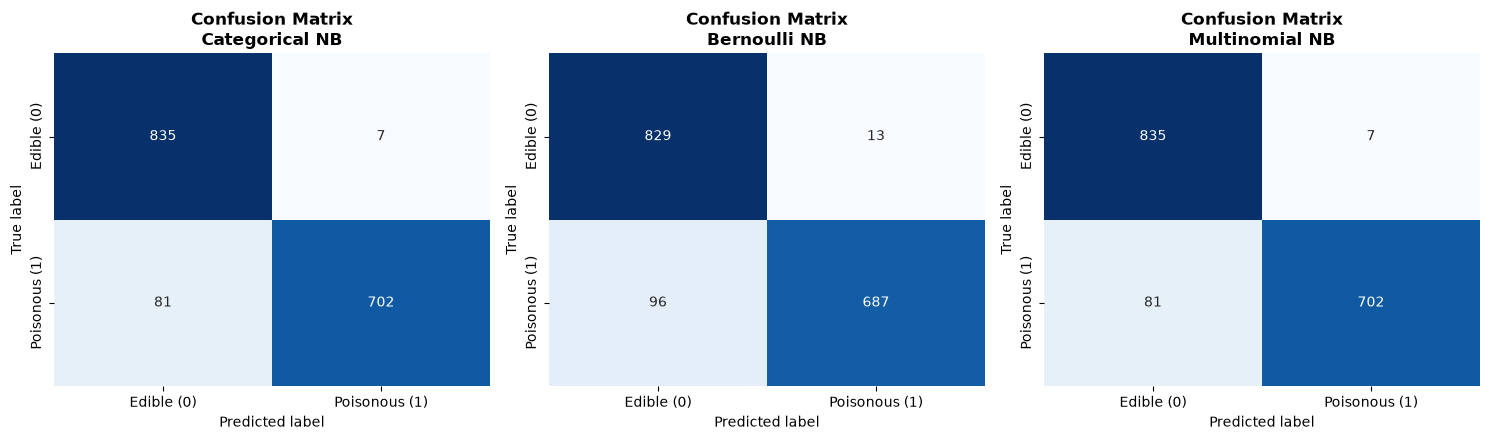

In [123]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
cm_cnb = confusion_matrix(y_test, y_pred_test_cnb)
cm_bnb = confusion_matrix(y_test, y_pred_test_bnb)
cm_mnb = confusion_matrix(y_test, y_pred_test_mnb)

fig, axes = plt.subplots(1, 3, figsize = (15, 4.5))

model_cms = [
    ("Categorical NB", cm_cnb),
    ("Bernoulli NB", cm_bnb),
    ("Multinomial NB", cm_mnb)
]

labels = ["Edible (0)", "Poisonous (1)"]

for ax, (title, cm) in zip(axes, model_cms):
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", ax = ax, xticklabels = labels, yticklabels = labels, cbar = False)
    ax.set_title(f"Confusion Matrix\n{title}", fontsize = 12, fontweight = "bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

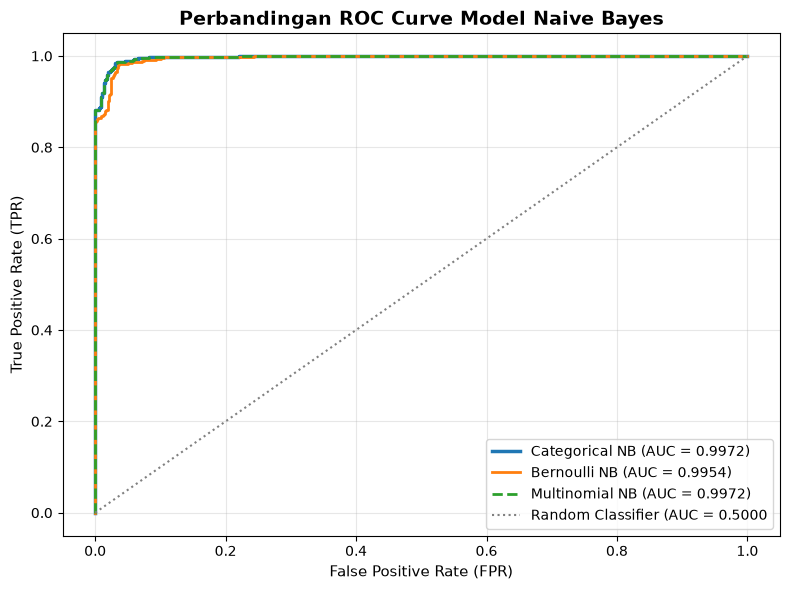

In [126]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_prob_cnb)
auc_cnb = auc(fpr_cnb, tpr_cnb)

fpr_bnb, tpr_bnb, _ = roc_curve(y_test, y_prob_bnb)
auc_bnb = auc(fpr_bnb, tpr_bnb)

fpr_mnb, tpr_mnb, _ = roc_curve(y_test, y_prob_mnb)
auc_mnb = auc(fpr_mnb, tpr_mnb)

plt.figure(figsize = (8, 6))
plt.plot(fpr_cnb, tpr_cnb, label = f"Categorical NB (AUC = {auc_cnb:.4f})", linewidth = 2.5)
plt.plot(fpr_bnb, tpr_bnb, label = f"Bernoulli NB (AUC = {auc_bnb:.4f})", linewidth = 2)
plt.plot(fpr_mnb, tpr_mnb, label = f"Multinomial NB (AUC = {auc_mnb:.4f})", linestyle = "--", linewidth = 2)

plt.plot([0,1], [0,1], color = "gray", linestyle = ":", label = "Random Classifier (AUC = 0.5000")

plt.title("Perbandingan ROC Curve Model Naive Bayes", fontsize = 14, fontweight = "bold")
plt.xlabel("False Positive Rate (FPR)", fontsize = 11)
plt.ylabel("True Positive Rate (TPR)", fontsize = 11)
plt.legend(loc = "lower right", fontsize = 10)
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

# Analisis Hasil Eksperimen dan Evaluasi Model Naive Bayes

## 1. Exploratory Data Analysis (EDA) & Preprocessing
* **Karakteristik Data**: Dataset jamur (*Mushroom*) terdiri dari fitur-fitur kategorikal murni tanpa adanya variabel numerik kontinu.
* **Penanganan Missing Values**: Kolom `stalk-root` yang memiliki *missing values* diimputasi menggunakan kategori baru `'missing'` agar tidak menghilangkan sampel informasi dari dataset.
* **Transformasi Fitur**:
  * **OrdinalEncoder**: Digunakan untuk mengubah variabel kategorikal menjadi nilai integer diskret sebagai input untuk **CategoricalNB**. Nilai tak dikenal (*unknown values*) pada data uji ditangani menggunakan parameter `unknown_value=-1`.
  * **OneHotEncoder**: Digunakan untuk memecah variabel kategorikal menjadi matriks biner ($0$ atau $1$) sebagai input untuk **BernoulliNB** dan **MultinomialNB** dengan konfigurasi `handle_unknown='ignore'`.

---

## 2. Hasil Evaluasi Performa Model

Pengujian dilakukan pada *test set* menggunakan 5 metrik evaluasi utama. Hasil yang diperoleh adalah sebagai berikut:

### Tabel Perbandingan Metrik Evaluasi

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Categorical NB** | **0.9458** | **0.9901** | **0.8966** | **0.9410** | **0.9972** |
| **Bernoulli NB** | 0.9329 | 0.9814 | 0.8774 | 0.9265 | 0.9954 |
| **Multinomial NB** | **0.9458** | **0.9901** | **0.8966** | **0.9410** | **0.9972** |

### Rincian Confusion Matrix
* **Categorical NB & Multinomial NB**:
  * **True Negative (TN)** = 835 (*Edible* tertebak *Edible*)
  * **True Positive (TP)** = 702 (*Poisonous* tertebak *Poisonous*)
  * **False Positive (FP)** = 7 (*Edible* salah ditebak sebagai *Poisonous*)
  * **False Negative (FN)** = 81 (*Poisonous* salah ditebak sebagai *Edible*) $\rightarrow$ **Kasus Paling Berbahaya**
* **Bernoulli NB**:
  * **True Negative (TN)** = 829
  * **True Positive (TP)** = 687
  * **False Positive (FP)** = 13
  * **False Negative (FN)** = 96 $\rightarrow$ **Meningkat 15 kasus dibanding CNB/MNB**

---

## 3. Analisis Perbandingan Performa & Representasi Data

### A. Ekuivalensi CategoricalNB dan MultinomialNB
Eksperimen menunjukkan bahwa **CategoricalNB** dan **MultinomialNB** menghasilkan skor metrik yang identik hingga 4 angka di belakang koma (Accuracy: **0.9458**, Recall: **0.8966**, ROC-AUC: **0.9972**).

* **Penyebab**: Pada data kategorikal murni yang ditransformasi menggunakan One-Hot Encoding, setiap sampel data hanya memiliki tepat satu nilai `1` untuk setiap variabel kategorinya. 
* **Impak Matematis**: Saat MultinomialNB menghitung perkalian *likelihood* pada fitur-fitur bernilai `1` tersebut, persamaan matematisnya terdistribusi secara ekuivalen dengan perhitungan distribusi kategorikal langsung yang dilakukan oleh CategoricalNB pada data hasil Ordinal Encoding.

### B. Penurunan Performa pada BernoulliNB
**BernoulliNB** mencatatkan performa terendah di semua metrik dengan **Recall 0.8774** dan **False Negative sebanyak 96 kasus**.

* **Penyebab**: BernoulliNB memperhitungkan kemunculan ($1$) dan ketiadaan ($0$) suatu fitur secara simetris dalam perhitungan peluang:
  $$P(X_i \mid Y) \quad \text{dan} \quad (1 - P(X_i \mid Y))$$
* **Impak Matematis**: Karena matriks One-Hot Encoding didominasi oleh angka `0` (*sparse matrix*), ketiadaan suatu fitur (misalnya ketiadaan warna topi tertentu) ikut dihitung sebagai bobot informasi oleh BernoulliNB. Menghitung ketiadaan fitur biner yang melimpah ini menciptakan *noise* tambahan yang menurunkan sensitivitas model, sehingga lebih banyak jamur beracun yang tidak terdeteksi (FN meningkat).


# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# Kesimpulan dan Saran

## 1. Kesimpulan

1. **Model Terbaik**: **CategoricalNB** dan **MultinomialNB** menghasilkan performa tertinggi dan identik pada seluruh metrik evaluasi (Accuracy: **0,9458**, Recall: **0,8966**, F1-Score: **0,9410**, dan ROC-AUC: **0,9972**).
2. **Efisiensi Algoritma**: **CategoricalNB** adalah varian paling direkomendasikan secara praktis. Penggunaan `OrdinalEncoder` pada CategoricalNB menjaga struktur data tetap ringkas tanpa perlu memekarkan dimensi matriks (*sparse matrix*) seperti pada One-Hot Encoding yang dibutuhkan MultinomialNB.
3. **Keterbatasan BernoulliNB**: **BernoulliNB** mencatatkan performa terendah (Recall: **0,8774**) dengan angka *False Negative* tertinggi (**96 kasus**). Hal ini disebabkan oleh sifat BernoulliNB yang memperhitungkan ketiadaan fitur (nilai $0$) sebagai bobot informasi, sehingga menimbulkan *noise* pada matriks biner hasil One-Hot Encoding.
4. **Evaluasi Keamanan Domain**: Asumsi independensi antarfitur pada Naive Bayes belum mampu menekan angka *False Negative* hingga $0$ (terdapat 81 jamur beracun yang salah diklasifikasikan sebagai *edible* pada model terbaik).

---

## 2. Saran

1. **Penyesuaian Ambang Batas Probabilitas (*Threshold Tuning*)**:
   * Secara standar, keputusan klasifikasi menggunakan *threshold* $0,5$. Mengingat risiko fatal dari *False Negative* pada kasus jamur beracun, eksperimen selanjutnya disarankan untuk menurunkan *threshold* probabilitas kelas *poisonous* (misalnya menjadi $0,2$ atau $0,3$) guna memaksimalkan *Recall* hingga mendekati $100\%$.

2. **Eksplorasi Algoritma Non-Probabilistik**:
   * Naive Bayes mengasumsikan seluruh fitur saling bebas (*independent*), padahal karakteristik fisik jamur (seperti bau, warna insang, dan bentuk spora) sering kali memiliki korelasi kuat. Eksperimen berikutnya disarankan menggunakan algoritma berbasis pohon seperti **Decision Tree** atau **Random Forest** yang dapat menangani interaksi antarfitur tanpa asumsi independensi.

3. **Seleksi Fitur (*Feature Selection*)**:
   * Melakukan analisis *Feature Importance* atau uji independensi Chi-Square untuk menyaring fitur-fitur yang paling dominan dalam membedakan jamur beracun (misalnya fitur `odor`), serta membuang fitur dengan *noise* tinggi untuk meningkatkan akurasi model.